In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.precision", 8)

# Use pre-processed csv
data_table = "../data/preprocessed_data.csv"
df = pd.read_csv(data_table, delimiter=",")

In [2]:
df['Survival outcome standardized'].value_counts()

Survival outcome standardized
CSS    335
OS     200
DFS     79
PFS     25
MFS     20
CRM     11
OM       8
Name: count, dtype: int64

In [3]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, MaxNLocator, LogLocator
from matplotlib.ticker import FuncFormatter, ScalarFormatter

def build_study_color_map(df: pd.DataFrame, seed: int = 0) -> dict:
    """
    Build a global PubmedID → color mapping from the full dataframe.
    """
    all_ids = sorted(df["PubmedID"].dropna().unique())
    palette = sns.color_palette("tab20", 20) + sns.color_palette("tab20b", 20)
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(len(palette)).tolist()
    colors = [palette[i] for i in shuffled]
    return {pid: colors[i % len(colors)] for i, pid in enumerate(all_ids)}


def plot_biomarker_forest_minimal(
    df: pd.DataFrame,
    outcome: str,
    min_studies: int = 5,
    *,
    study_color_map: dict | None = None,
    fig_size=(12, 4),
    row_height=0.55,
    legend_pos=[1.0, 0.72],
    jitter=0.16,
    seed: int = 0,
    xlim=(0.2, 80),
    title: str | None = None,
    dpi=None,
    savepath: str | None = None,
):
    plot_df = df.copy()
    plot_df = plot_df[plot_df["Survival outcome standardized"] == outcome].copy()
    plot_df = plot_df[
        plot_df["HR_pick"].notna()
        & plot_df["P_value_num"].notna()
        & (plot_df["HR_pick"] > 0)
    ].copy()

    if plot_df.empty:
        raise ValueError(f"No valid rows after filtering for outcome='{outcome}'.")

    forest = (
        plot_df.groupby("Biomarker name")
        .agg(
            n=("PubmedID", "nunique"),
            HR_median=("HR_pick", "median"),
            HR_q25=("HR_pick", lambda x: x.quantile(0.25)),
            HR_q75=("HR_pick", lambda x: x.quantile(0.75)),
            prop_sig=("P_value_num", lambda x: (x < 0.05).mean()),
        )
        .reset_index()
    )

    forest = forest[forest["n"] >= min_studies].copy()
    if forest.empty:
        raise ValueError(
            f"No biomarkers have at least min_studies={min_studies} for outcome='{outcome}'."
        )

    forest = forest.sort_values("HR_median").reset_index(drop=True)
    biomarkers = forest["Biomarker name"].tolist()
    y_map = {b: i for i, b in enumerate(biomarkers)}

    pts = plot_df[plot_df["Biomarker name"].isin(biomarkers)].copy()
    pts["y"] = pts["Biomarker name"].map(y_map).astype(float)

    # jitter
    rng = np.random.default_rng(seed)
    pts["y_jit"] = pts["y"] + rng.uniform(-jitter, jitter, size=len(pts))

    # significance flag
    pts["significant"] = pts["P_value_num"] < 0.05

    # marker shape by analysis type
    pts["marker"] = np.where(pts["HR_picked_from"] == "Multivariate", "D", "^")

    # Results per (biomarker, study)
    bar_data = (
        pts.groupby(["Biomarker name", "PubmedID"])
        .size()
        .reset_index(name="n_results")
    )

    # Order studies consistently by total results
    study_totals = bar_data.groupby("PubmedID")["n_results"].sum().sort_values(ascending=False)
    study_order = study_totals.index.tolist()

    # Pivot to (biomarker x study) matrix, aligned to forest row order
    bar_pivot = (
        bar_data.pivot(index="Biomarker name", columns="PubmedID", values="n_results")
        .reindex(index=biomarkers, columns=study_order)
        .fillna(0)
    )

    # Colour palette — one colour per study, grey for studies with 0 results
    n_studies = len(study_order)
    palette = sns.color_palette("tab20", 30)[2:]
    study_colors = dict(zip(study_order, palette[:n_studies]))

    if study_color_map is not None:
        local_color_map = study_color_map
    else:
        fallback_palette = sns.color_palette("tab20", 20) + sns.color_palette("tab20b", 20)
        local_color_map = {pid: fallback_palette[i % len(fallback_palette)]
                           for i, pid in enumerate(study_order)}


    row_color = ["0.75" if p == 0 else "black" for p in forest["prop_sig"]]

    # Layout
    sns.set_theme(style="whitegrid")

    fig, (ax, ax2) = plt.subplots(
        1, 2,
        figsize=fig_size,
        gridspec_kw={"width_ratios": [3, 1]},
        sharey=True
    )
    fig.subplots_adjust(wspace=0.05)

    # Forest plot
    for i in range(len(forest)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.97", zorder=0)
            ax2.axhspan(i - 0.5, i + 0.5, color="0.97", zorder=0)

    ax.grid(axis="x", which="major", color="0.88", linewidth=0.8)
    ax.grid(axis="x", which="minor", color="0.94", linewidth=0.5)
    ax.grid(axis="y", visible=False)

    ax.hlines(
        y=np.arange(len(forest)),
        xmin=forest["HR_q25"],
        xmax=forest["HR_q75"],
        color="0.45",
        alpha=0.8,
        linewidth=2.2,
        zorder=2,
    )

    sc = ax.scatter(
        forest["HR_median"],
        np.arange(len(forest)),
        c=forest["prop_sig"],
        cmap="Blues",
        vmin=0, vmax=1,
        s=110,
        edgecolors="black",
        linewidths=0.5,
        zorder=3,
    )

    # individual study points
    for marker, label in [("^", "Univariate"), ("D", "Multivariate")]:
        sub = pts[pts["marker"] == marker].copy()

        # non-significant
        sub_ns = sub[~sub["significant"]]
        ax.scatter(
            sub_ns["HR_pick"],
            sub_ns["y_jit"],
            marker=marker,
            c="0.6",
            alpha=0.3,
            s=34,
            linewidths=0,
            zorder=4,
        )

        # significant
        sub_sig = sub[sub["significant"]]
        ax.scatter(
            sub_sig["HR_pick"],
            sub_sig["y_jit"],
            marker=marker,
            c="0.6",
            alpha=0.4,
            s=44,
            edgecolors="black",
            linewidths=0.7,
            zorder=5,
        )

    ax.set_xscale("log")
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=[0.2, 0.4, 0.6, 0.8]))
    ax.xaxis.set_minor_formatter(ScalarFormatter())
    ax.tick_params(axis="x", which="minor", labelsize=8)
    ax.axvline(1, linestyle="--", linewidth=1.4, color="0.35", zorder=1)
    ax.set_xlim(*xlim)

    ax.set_yticks(np.arange(len(forest)))
    ax.set_yticklabels(forest["Biomarker name"], fontsize=10)
    for tick, color in zip(ax.get_yticklabels(), row_color):
        tick.set_color(color)
    ax.set_xlabel("Hazard ratio (log scale)", fontsize=11)
    ax.set_ylabel("")

    if title is None:
        title = f"{outcome} associations across biomarkers"
    ax.set_title(title, fontsize=13, pad=12, weight="bold")

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("0.7")
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", length=0)

    # Stacked bar panel
    lefts = np.zeros(len(biomarkers))
    y_pos = np.arange(len(biomarkers))

    for study in study_order:
        vals = bar_pivot[study].values
        ax2.barh(
            y_pos,
            vals,
            left=lefts,
            height=0.6,
            color=[local_color_map.get(study, "0.8") if v > 0 else "none" for v in vals],
            edgecolor="white",
            linewidth=0.4,
            zorder=2,
        )
        lefts += vals

    # Total count label at the end of each bar
    for i, total in enumerate(lefts):
        ax2.text(total + 0.15, i, str(int(total)),
                 va="center", ha="left", fontsize=8, color="0.4")

    ax2.set_xlim(0, bar_pivot.sum(axis=1).max() + 3)
    ax2.set_xlabel("Number of results", fontsize=11)
    ax2.set_title("Results per study", fontsize=11, pad=12)
    ax2.grid(axis="y", visible=False)

    ax2.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=3))
    ax2.grid(axis="x", which="major", color="0.88", linewidth=0.8, zorder=0)
    ax2.grid(axis="x", which="minor", color="0.94", linewidth=0.5, zorder=0)
    ax2.tick_params(axis="x", which="minor", labelsize=8)

    for spine in ["top", "right", "left"]:
        ax2.spines[spine].set_visible(False)
    ax2.spines["bottom"].set_color("0.7")
    ax2.tick_params(axis="y", length=0)
    ax2.tick_params(axis="x", labelsize=10)

    # legends
    significance_handles = [
        Line2D(
            [0], [0],
            marker="o",
            markerfacecolor="0.75",
            markeredgecolor="black",
            alpha=0.5,
            linestyle="None",
            markersize=7,
            label="p < 0.05",
        ),
        Line2D(
            [0], [0],
            marker="o",
            markerfacecolor="0.75",
            markeredgecolor="none",
            alpha=0.5,
            linestyle="None",
            markersize=7,
            label="p ≥ 0.05",
        ),
    ]
    marker_handles = [
        Line2D([0], [0], marker="^", color="black", linestyle="None", markersize=6, label="Univariate"),
        Line2D([0], [0], marker="D", color="black", linestyle="None", markersize=6, label="Multivariate"),
    ]
    leg1 = ax.legend(
        handles=significance_handles,
        title="Significance",
        frameon=False,
        bbox_to_anchor=(1.65, legend_pos[1]),
        loc="upper left",
        borderaxespad=0,
        fontsize=9,
        title_fontsize=10
    )
    leg1.get_title().set_ha("left")
    leg2 = ax.legend(
        handles=marker_handles,
        title="Analysis type",
        frameon=False,
        bbox_to_anchor=(1.65, legend_pos[0]),
        loc="upper left",
        borderaxespad=0,
        fontsize=9,
        title_fontsize=10
    )
    leg2.get_title().set_ha("left")
    ax.add_artist(leg1)

    # Colorbar
    cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label("Proportion significant\n(p < 0.05)", fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_visible(False)

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", dpi=dpi)

    return fig, ax, ax2, forest, pts, bar_pivot

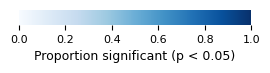

In [4]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig_cb, ax_cb = plt.subplots(figsize=(3, 0.4))
fig_cb.subplots_adjust(bottom=0.5)

sc = cm.ScalarMappable(cmap="Blues", norm=mcolors.Normalize(vmin=0, vmax=1))
sc.set_array([])

cbar = fig_cb.colorbar(sc, cax=ax_cb, orientation="horizontal")
cbar.set_label("Proportion significant (p < 0.05)", fontsize=9)
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_visible(False)

plt.savefig("figures/comparative_statistics_colorbar.pdf", bbox_inches="tight")
plt.savefig("figures/comparative_statistics_colorbar.png", dpi=600, bbox_inches="tight")

/var/folders/ml/ckydwkhn4zjbmx3s2k4ss7fckdkbsq/T/ipykernel_77666/474144889.py:195: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(*xlim)


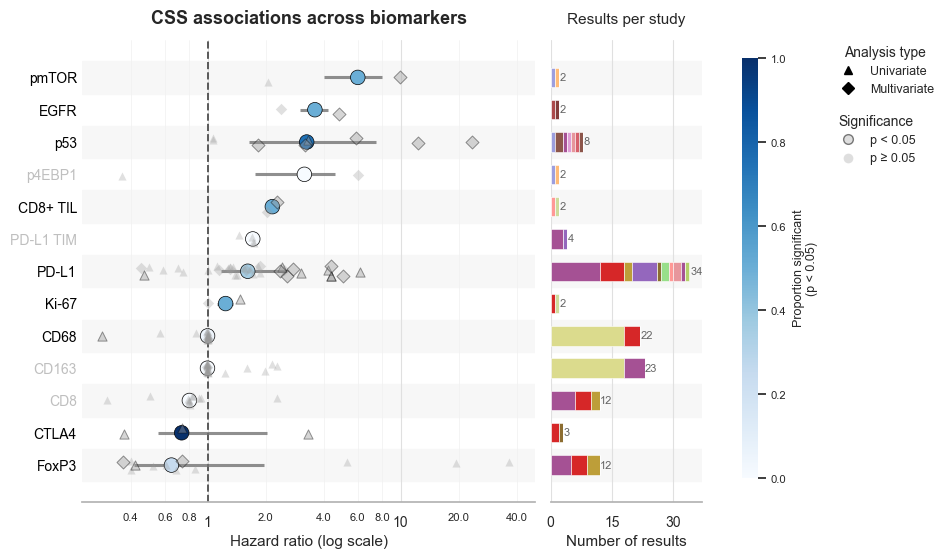

In [6]:
plot_biomarker_forest_minimal(
    df,
    outcome="CSS",
    study_color_map=build_study_color_map(df, seed=42),
    min_studies=2,
    legend_pos=[1.0, 0.85],
    xlim=(0, 50),
    savepath="figures/comparative_statistics_css_min2.png",
    fig_size=(8,6),
    dpi=600
)
plt.show()

/var/folders/ml/ckydwkhn4zjbmx3s2k4ss7fckdkbsq/T/ipykernel_77666/474144889.py:195: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(*xlim)


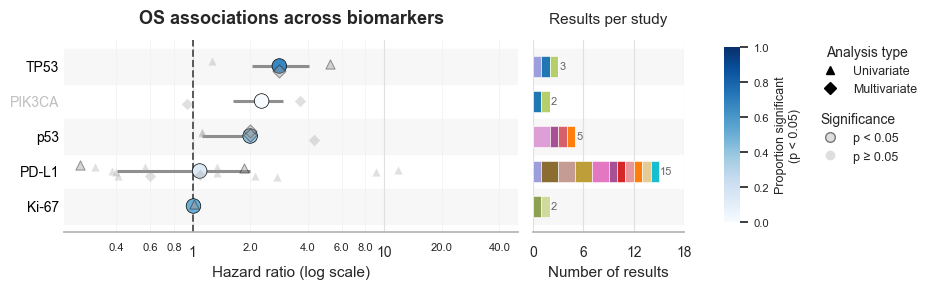

In [7]:
plot_biomarker_forest_minimal(
    df,
    outcome="OS",
    study_color_map=build_study_color_map(df, seed=42),
    min_studies=2,
    legend_pos=[1.0, 0.65],
    xlim=(0, 50),
    savepath="figures/comparative_statistics_os_min2.png",
    fig_size=(8,2.5),
    dpi=600
)
plt.show()

/var/folders/ml/ckydwkhn4zjbmx3s2k4ss7fckdkbsq/T/ipykernel_77666/474144889.py:195: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(*xlim)


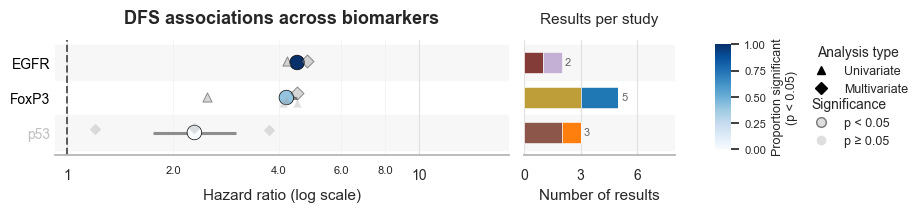

In [8]:
plot_biomarker_forest_minimal(
    df,
    outcome="DFS",
    study_color_map=build_study_color_map(df, seed=42),
    min_studies=2,
    legend_pos=[1.0, 0.55],
    xlim=(-1, 18),
    savepath="figures/comparative_statistics_dfs_min2.png",
    fig_size=(8,1.5),
    dpi=600
)
plt.show()

/var/folders/ml/ckydwkhn4zjbmx3s2k4ss7fckdkbsq/T/ipykernel_77666/474144889.py:195: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(*xlim)


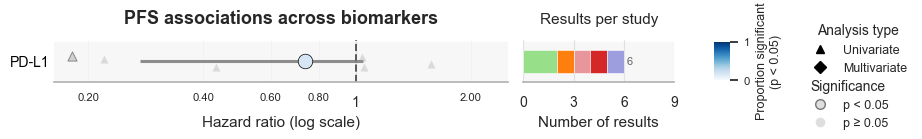

In [9]:
plot_biomarker_forest_minimal(
    df,
    outcome="PFS",
    study_color_map=build_study_color_map(df, seed=42),
    min_studies=2,
    legend_pos=[1.5, 0.2],
    xlim=(0, 2.5),
    savepath="figures/comparative_statistics_pfs_min2.png",
    fig_size=(8,.55),
    dpi=600
)
plt.show()